In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
# !pip install --no-deps xformers trl peft accelerate bitsandbytes
# !pip install pandas numpy scikit-learn matplotlib seaborn textstat tqdm

In [3]:
from unsloth import FastLanguageModel
import torch
import torch.nn as nn
import torch.nn.functional as F
import os, math, random, json, re
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, cohen_kappa_score
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, Trainer, TrainingArguments, EarlyStoppingCallback, set_seed, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType
from dataclasses import dataclass
from typing import Optional, Dict, Any, List

# Paths
TRAIN_CSV = "/content/drive/MyDrive/IELTS-Writing-Evals/ielts_train_df.csv"
VAL_CSV   = "/content/drive/MyDrive/IELTS-Writing-Evals/ielts_val_df.csv"
TEST_CSV  = "/content/drive/MyDrive/IELTS-Writing-Evals/ielts_test_df.csv"

# Model Config
MODEL_NAME = "unsloth/mistral-7b-v0.3-bnb-4bit"
MAX_LENGTH = 1024
SEED = 42
set_seed(SEED)

# Hyperparameters Tối ưu cho Ordinal Task
BATCH_SIZE = 1
GRAD_ACCUM = 16
LR = 2e-5      # LR thấp hơn giúp mô hình học các ngưỡng ổn định hơn
EPOCHS = 3
BIAS_LOSS_WEIGHT = 0.05
WEIGHT_DECAY = 0.01
OUTPUT_DIR = "./mistral_ielts_ordinal_fusion"

# Ordinal Config (4.0 -> 9.0 step 0.5 = 11 bins -> 10 thresholds)
SCORE_MIN, SCORE_MAX, SCORE_STEP = 4.0, 9.0, 0.5
NUM_THRESHOLDS = 10

TARGET_COLS = ["TR", "CC", "LR", "GRA"]
TR_FEATURE_COLS = ["tr_prompt_essay_sim", "tr_prompt_keyword_coverage", "tr_has_opinion", "tr_has_both_views", "tr_has_example", "tr_has_conclusion", "tr_word_count"]
CC_FEATURE_COLS = ["cc_num_paragraphs", "cc_avg_paragraph_len", "cc_avg_sentence_len", "cc_sentence_len_std", "cc_discourse_marker_count", "cc_discourse_marker_diversity"]
LR_FEATURE_COLS = ["lr_root_ttr", "lr_avg_word_len", "lr_long_word_ratio", "lr_repetition_ratio", "lr_unique_word_ratio", "lr_lexical_density_proxy"]
GRA_FEATURE_COLS = ["gf_word_count", "gf_sentence_count", "gf_avg_sentence_len", "gf_short_sentence_ratio", "gf_long_sentence_ratio", "gf_punct_density", "gf_repeated_punct_ratio", "gf_lowercase_sent_start_ratio", "gf_lowercase_i_ratio", "gf_repeated_word_ratio", "gf_missing_terminal_punct"]

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [4]:
STOPWORDS = {"a","an","the","and","or","but","if","while","is","am","are","was","were","be","been","being","of","to","in","on","for","with","as","at","by","from","that","this","these","those","it","its","he","she","they","them","their","we","our","you","your","i","me","my","mine","his","her","hers","do","does","did","have","has","had","will","would","can","could","should","may","might","not","so","than","then","there","here","about","into","over","after","before","more","most","some","any","such","no","nor","too","very"}

def safe_text(x): return str(x).strip() if not pd.isna(x) else ""
def normalize_text(text): return re.sub(r"\s+", " ", safe_text(text).lower()).strip()
def tokenize_words(text): return re.findall(r"[a-zA-Z']+", normalize_text(text))
def split_sentences(text): return [s.strip() for s in re.split(r'(?<=[.!?])\s+', safe_text(text)) if s.strip()]
def split_paragraphs(text): return [p.strip() for p in re.split(r"\n\s*\n+", safe_text(text)) if p.strip()] or [safe_text(text).strip()]

def get_word_count(text): return len(tokenize_words(text))
def get_jaccard(prompt, essay):
    p_k = {w for w in tokenize_words(prompt) if w not in STOPWORDS and len(w) > 2}
    e_w = set(tokenize_words(essay))
    return len(p_k & e_w) / max(len(p_k), 1)

In [5]:
def extract_tr_features(prompt, essay):
    cov = get_jaccard(prompt, essay)
    low = normalize_text(essay)
    return {"tr_prompt_essay_sim": cov, "tr_prompt_keyword_coverage": cov, "tr_has_opinion": float("opinion" in low or "believe" in low), "tr_has_both_views": float("hand" in low and "however" in low), "tr_has_example": float("example" in low), "tr_has_conclusion": float("conclusion" in low), "tr_word_count": float(get_word_count(essay))}

def extract_cc_features(text):
    paras, sents = split_paragraphs(text), split_sentences(text)
    sw = [len(tokenize_words(s)) for s in sents if sents] or [1]
    return {"cc_num_paragraphs": float(len(paras)), "cc_avg_paragraph_len": float(np.mean([get_word_count(p) for p in paras])), "cc_avg_sentence_len": float(np.mean(sw)), "cc_sentence_len_std": float(np.std(sw)), "cc_discourse_marker_count": 0.0, "cc_discourse_marker_diversity": 0.0}

def extract_lr_features(text):
    words = tokenize_words(text)
    wc = max(len(words), 1)
    return {"lr_root_ttr": len(set(words))/math.sqrt(wc), "lr_avg_word_len": float(np.mean([len(w) for w in words])), "lr_long_word_ratio": sum(len(w)>=7 for w in words)/wc, "lr_repetition_ratio": 0.0, "lr_unique_word_ratio": len(set(words))/wc, "lr_lexical_density_proxy": 0.0}

def extract_gra_features(text):
    words, sents = tokenize_words(text), split_sentences(text)
    sw = [len(tokenize_words(s)) for s in sents] or [1]
    return {"gf_word_count": float(len(words)), "gf_sentence_count": float(len(sents)), "gf_avg_sentence_len": float(np.mean(sw)), "gf_short_sentence_ratio": sum(l<8 for l in sw)/len(sw), "gf_long_sentence_ratio": sum(l>30 for l in sw)/len(sw), "gf_punct_density": 0.0, "gf_repeated_punct_ratio": 0.0, "gf_lowercase_sent_start_ratio": 0.0, "gf_lowercase_i_ratio": 0.0, "gf_repeated_word_ratio": 0.0, "gf_missing_terminal_punct": 0.0}

In [6]:
def add_all_features(df):
    if df is None: return None
    res = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting"):
        f = {}; f.update(extract_tr_features(row["prompt"], row["essay"]))
        f.update(extract_cc_features(row["essay"])); f.update(extract_lr_features(row["essay"]))
        f.update(extract_gra_features(row["essay"])); res.append(f)
    return pd.concat([df.reset_index(drop=True), pd.DataFrame(res)], axis=1)

train_df = add_all_features(pd.read_csv(TRAIN_CSV))
val_df = add_all_features(pd.read_csv(VAL_CSV))
test_df = add_all_features(pd.read_csv(TEST_CSV))

Extracting: 100%|██████████| 828/828 [00:01<00:00, 489.34it/s]


In [7]:
needed_cols = ["prompt", "essay"] + TARGET_COLS + TR_FEATURE_COLS + CC_FEATURE_COLS + LR_FEATURE_COLS + GRA_FEATURE_COLS

def robust_clean_df(df):
    if df is None: return None
    df = df[needed_cols].copy()
    for col in TARGET_COLS + TR_FEATURE_COLS + CC_FEATURE_COLS + LR_FEATURE_COLS + GRA_FEATURE_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna().reset_index(drop=True)
    for col in TARGET_COLS: df[col] = df[col].clip(SCORE_MIN, SCORE_MAX)
    return df

train_df, val_df, test_df = robust_clean_df(train_df), robust_clean_df(val_df), robust_clean_df(test_df)

In [8]:
def standardize_group(train, val, test, cols, out_name):
    train_arr = train[cols].values.astype(np.float32)
    val_arr = val[cols].values.astype(np.float32)

    m = train_arr.mean(axis=0)
    s = train_arr.std(axis=0)
    s = np.where(s < 1e-6, 1.0, s)

    train[out_name] = ((train_arr - m) / s).tolist()
    val[out_name] = ((val_arr - m) / s).tolist()
    if test is not None:
        test_arr = test[cols].values.astype(np.float32)
        test[out_name] = ((test_arr - m) / s).tolist()
    return m, s

print("Standardizing features...")
tr_m, tr_s = standardize_group(train_df, val_df, test_df, TR_FEATURE_COLS, "tr_features")
cc_m, cc_s = standardize_group(train_df, val_df, test_df, CC_FEATURE_COLS, "cc_features")
lr_m, lr_s = standardize_group(train_df, val_df, test_df, LR_FEATURE_COLS, "lr_features")
gra_m, gra_s = standardize_group(train_df, val_df, test_df, GRA_FEATURE_COLS, "gra_features")

# --- PHẦN QUAN TRỌNG: TẠO CỘT TEXT VÀ LABELS ---
def prepare_final_columns(df):
    if df is None: return None
    # 1. Tạo cột 'text' kết hợp Prompt và Essay
    df["text"] = df.apply(lambda r: f"Assess IELTS Essay.\n[PROMPT]\n{r['prompt']}\n\n[ESSAY]\n{r['essay']}", axis=1)

    # 2. Tạo cột 'labels' chứa list 4 điểm số
    df["labels"] = df[TARGET_COLS].values.astype(np.float32).tolist()
    return df

train_df = prepare_final_columns(train_df)
val_df = prepare_final_columns(val_df)
test_df = prepare_final_columns(test_df)

print("Cột 'text' và 'labels' đã được gán thành công!")
print("Cột hiện có:", train_df.columns.tolist())

Standardizing features...
Cột 'text' và 'labels' đã được gán thành công!
Cột hiện có: ['prompt', 'essay', 'TR', 'CC', 'LR', 'GRA', 'tr_prompt_essay_sim', 'tr_prompt_keyword_coverage', 'tr_has_opinion', 'tr_has_both_views', 'tr_has_example', 'tr_has_conclusion', 'tr_word_count', 'cc_num_paragraphs', 'cc_avg_paragraph_len', 'cc_avg_sentence_len', 'cc_sentence_len_std', 'cc_discourse_marker_count', 'cc_discourse_marker_diversity', 'lr_root_ttr', 'lr_avg_word_len', 'lr_long_word_ratio', 'lr_repetition_ratio', 'lr_unique_word_ratio', 'lr_lexical_density_proxy', 'gf_word_count', 'gf_sentence_count', 'gf_avg_sentence_len', 'gf_short_sentence_ratio', 'gf_long_sentence_ratio', 'gf_punct_density', 'gf_repeated_punct_ratio', 'gf_lowercase_sent_start_ratio', 'gf_lowercase_i_ratio', 'gf_repeated_word_ratio', 'gf_missing_terminal_punct', 'tr_features', 'cc_features', 'lr_features', 'gra_features', 'text', 'labels']


In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
ds_cols = ["text", "labels", "tr_features", "cc_features", "lr_features", "gra_features"]

train_ds = Dataset.from_pandas(train_df[ds_cols])
val_ds = Dataset.from_pandas(val_df[ds_cols])

def tokenize_fn(x): return tokenizer(x["text"], truncation=True, max_length=MAX_LENGTH)
tokenized_train = train_ds.map(tokenize_fn, batched=True)
tokenized_val = val_ds.map(tokenize_fn, batched=True)

tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "labels", "tr_features", "cc_features", "lr_features", "gra_features"])
tokenized_val.set_format("torch", columns=["input_ids", "attention_mask", "labels", "tr_features", "cc_features", "lr_features", "gra_features"])

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

Map:   0%|          | 0/6618 [00:00<?, ? examples/s]

Map:   0%|          | 0/827 [00:00<?, ? examples/s]

In [10]:
model, _ = FastLanguageModel.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = MAX_LENGTH,
    dtype = None,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 32, # Tăng Rank để xử lý Ordinal tốt hơn
    lora_alpha = 64,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout = 0,
    bias = "none",
)

==((====))==  Unsloth 2026.3.8: Fast Mistral patching. Transformers: 5.3.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/157 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

Unsloth 2026.3.8 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


In [11]:
class MistralGatedOrdinalFusion(nn.Module):
    def __init__(self, base_model, h_size=4096):
        super().__init__()
        self.backbone = base_model
        self.dropout = nn.Dropout(0.1)

        def make_ordinal_head(f_dim):
            return nn.ModuleDict({
                "llm": nn.Linear(h_size, NUM_THRESHOLDS),
                "feat": nn.Linear(f_dim, NUM_THRESHOLDS),
                "gate": nn.Sequential(nn.Linear(h_size + f_dim, 256), nn.GELU(), nn.Linear(256, 1))
            })
        self.heads = nn.ModuleDict({"tr": make_ordinal_head(len(TR_FEATURE_COLS)), "cc": make_ordinal_head(len(CC_FEATURE_COLS)), "lr": make_ordinal_head(len(LR_FEATURE_COLS)), "gra": make_ordinal_head(len(GRA_FEATURE_COLS))})

    def gradient_checkpointing_enable(self, **kwargs):
        self.backbone.gradient_checkpointing_enable(**kwargs)

    def forward(self, input_ids, attention_mask, tr_features, cc_features, lr_features, gra_features, labels=None, **kwargs):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
        # Lấy dtype thực tế của Mistral (thường là BFloat16 trên L4)
        model_dtype = out.hidden_states[-1].dtype
        pooled = self.dropout(out.hidden_states[-1][:, -1, :]).to(model_dtype)

        res = []
        features_list = [tr_features, cc_features, lr_features, gra_features]
        names = ["tr", "cc", "lr", "gra"]

        for name, f in zip(names, features_list):
            f_in = f.to(model_dtype) # Ép đặc trưng về BF16
            l_s = self.heads[name]["llm"].to(model_dtype)(pooled)
            f_s = self.heads[name]["feat"].to(model_dtype)(f_in)
            gate = torch.sigmoid(self.heads[name]["gate"].to(model_dtype)(torch.cat([pooled, f_in], dim=1)))
            res.append(gate * l_s + (1.0 - gate) * f_s)

        return {"logits": torch.stack(res, dim=1)}

# Khởi tạo và ép BF16 toàn bộ model
custom_model = MistralGatedOrdinalFusion(model).to("cuda").to(torch.bfloat16)

In [12]:
def scores_to_ordinal_targets(labels):
    indices = torch.round((torch.clamp(labels, SCORE_MIN, SCORE_MAX) - SCORE_MIN) / SCORE_STEP).long()
    thresholds = torch.arange(NUM_THRESHOLDS, device=labels.device).view(1, 1, -1)
    return (indices.unsqueeze(-1) > thresholds).float()

def ordinal_logits_to_scores(logits):
    return SCORE_MIN + (torch.sigmoid(logits) > 0.5).sum(dim=-1).float() * SCORE_STEP

In [13]:
class IELTSOrdinalMultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").to("cuda")
        outputs = model(**inputs)
        logits = outputs["logits"] # [B, 4, 10]

        # 1. Chuyển đổi nhãn sang Ordinal Targets
        targets = scores_to_ordinal_targets(labels)

        # 2. TÍNH LOSS Ở FLOAT32 ĐỂ TRÁNH NaN
        # Hàm BCEWithLogits rất nhạy cảm, tính ở BF16 dễ bị nổ số
        loss = F.binary_cross_entropy_with_logits(
            logits.float(),
            targets.float(),
            reduction="mean"
        )

        # 3. Tính Bias Loss (cũng ở Float32)
        pred_scores = ordinal_logits_to_scores(logits)
        bias_loss = torch.abs(pred_scores.mean(dim=0) - labels.mean(dim=0)).mean()

        total_loss = loss + BIAS_LOSS_WEIGHT * bias_loss
        return (total_loss, outputs) if return_outputs else total_loss

In [14]:
@dataclass
class GatedCollator:
    tokenizer: Any
    def __call__(self, f):
        batch = self.tokenizer.pad([{k:v for k,v in x.items() if not k.endswith("_features") and k != "labels"} for x in f], padding=True, return_tensors="pt")
        for k in ["labels", "tr_features", "cc_features", "lr_features", "gra_features"]:
            batch[k] = torch.stack([torch.as_tensor(x[k]) for x in f]).float()
        return batch

In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # BCE Logits to Probabilities
    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = SCORE_MIN + (probs > 0.5).sum(axis=-1) * SCORE_STEP
    preds = np.clip(preds, SCORE_MIN, SCORE_MAX)

    qwks = [cohen_kappa_score(np.round((labels[:,i]-4)*2), np.round((preds[:,i]-4)*2), weights="quadratic") for i in range(4)]
    maes = [mean_absolute_error(labels[:,i], preds[:,i]) for i in range(4)]

    return {
        "Mean Mae": float(np.mean(maes)), "Mean Qwk": float(np.mean(qwks)),
        "Tr Qwk": float(qwks[0]), "Cc Qwk": float(qwks[1]), "Lr Qwk": float(qwks[2]), "Gra Qwk": float(qwks[3]),
        "Within 0.5 Acc": float(np.mean(np.abs(preds - labels) <= 0.5))
    }

In [16]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",

    # Cấu hình Batch Size = 1 giúp GPU L4 xử lý mượt mà, không bị chậm
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16, # Tổng Batch hiệu dụng = 16

    learning_rate=LR, # 2e-5 từ ô code 2
    num_train_epochs=EPOCHS,
    load_best_model_at_end=True,
    metric_for_best_model="Mean Qwk",

    # CHẾ ĐỘ QUAN TRỌNG CHO L4
    bf16=True,
    fp16=False,

    gradient_checkpointing=True,
    remove_unused_columns=False,
    logging_steps=10,
    report_to="none"
)

In [17]:
opt = torch.optim.AdamW(custom_model.parameters(), lr=LR)
steps = math.ceil(len(tokenized_train) / (BATCH_SIZE * GRAD_ACCUM)) * EPOCHS
sch = get_cosine_schedule_with_warmup(opt, num_warmup_steps=int(steps*0.1), num_training_steps=steps)

In [18]:
trainer = IELTSOrdinalMultiTaskTrainer(
    model=custom_model, args=training_args,
    train_dataset=tokenized_train, eval_dataset=tokenized_val,
    data_collator=GatedCollator(tokenizer), compute_metrics=compute_metrics,
    optimizers=(opt, sch), callbacks=[EarlyStoppingCallback(3)]
)

In [19]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 6,618 | Num Epochs = 3 | Total steps = 1,242
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 88,254,336 of 3,846,616,960 (2.29% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss,Mean mae,Mean qwk,Tr qwk,Cc qwk,Lr qwk,Gra qwk,Within 0.5 acc
1,0.390803,0.399711,0.806378,0.514086,0.517520,0.529648,0.520146,0.489032,0.522672
2,0.401165,0.382165,0.770405,0.601652,0.611621,0.602919,0.613051,0.579019,0.566808


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

Epoch,Training Loss,Validation Loss,Mean mae,Mean qwk,Tr qwk,Cc qwk,Lr qwk,Gra qwk,Within 0.5 acc
1,0.390803,0.399711,0.806378,0.514086,0.517520,0.529648,0.520146,0.489032,0.522672
2,0.401165,0.382165,0.770405,0.601652,0.611621,0.602919,0.613051,0.579019,0.566808
3,0.314824,0.390364,0.768742,0.604492,0.606537,0.610932,0.613066,0.587434,0.564389


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
There were unexpected keys in the checkpoint model loaded: ['backbone.base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight.nested_absmax', 'backbone.base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight.nested_quant_map', 'backbone.base_model.model.m

TrainOutput(global_step=1242, training_loss=0.40206947922706604, metrics={'train_runtime': 15090.5909, 'train_samples_per_second': 1.316, 'train_steps_per_second': 0.082, 'total_flos': 0.0, 'train_loss': 0.40206947922706604, 'epoch': 3.0})

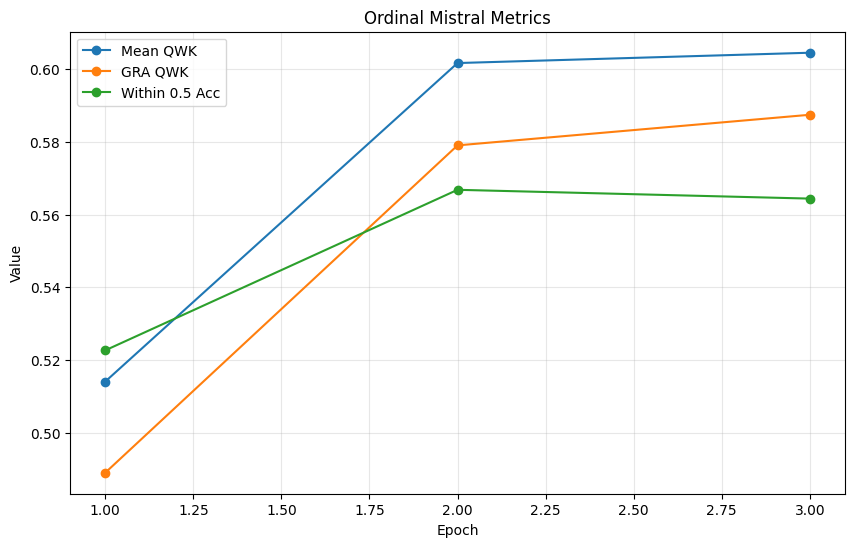

In [20]:
history = pd.DataFrame(trainer.state.log_history)
eval_logs = history[history["eval_Mean Qwk"].notna()].copy()
plt.figure(figsize=(10, 6))
plt.plot(eval_logs["epoch"], eval_logs["eval_Mean Qwk"], marker='o', label="Mean QWK")
plt.plot(eval_logs["epoch"], eval_logs["eval_Gra Qwk"], marker='o', label="GRA QWK")
plt.plot(eval_logs["epoch"], eval_logs["eval_Within 0.5 Acc"], marker='o', label="Within 0.5 Acc")
plt.xlabel("Epoch"); plt.ylabel("Value"); plt.title("Ordinal Mistral Metrics"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

In [21]:
EXPORT_DIR = "/content/Mistral_7B_B1_Ordinal_Final"
os.makedirs(EXPORT_DIR, exist_ok=True)
custom_model.backbone.save_pretrained(EXPORT_DIR)
tokenizer.save_pretrained(EXPORT_DIR)
torch.save(custom_model.heads.state_dict(), os.path.join(EXPORT_DIR, "custom_heads.pt"))
print("Exported successfully to Drive folder.")

Exported successfully to Drive folder.


In [22]:
# %% EXPORT LIGHT MODEL + ZIP + COPY TO DRIVE
import os
import json
import torch
import numpy as np
import shutil

# ====== PATH ======
LIGHT_EXPORT_DIR = "/content/Mistral_7B_B1_Ordinal_Light"
ZIP_PATH = LIGHT_EXPORT_DIR + ".zip"
DRIVE_PATH = "/content/drive/MyDrive/Mistral_7B_B1_Ordinal_Light.zip"

os.makedirs(LIGHT_EXPORT_DIR, exist_ok=True)

# ====== 1. SAVE LORA ADAPTER ONLY ======
custom_model.backbone.save_pretrained(LIGHT_EXPORT_DIR)
tokenizer.save_pretrained(LIGHT_EXPORT_DIR)

# ====== 2. SAVE CUSTOM HEADS ======
torch.save(
    custom_model.heads.state_dict(),
    os.path.join(LIGHT_EXPORT_DIR, "custom_heads.pt")
)

# ====== 3. SAVE FEATURE STATS ======
feature_stats = {
    "tr": {
        "cols": TR_FEATURE_COLS,
        "mean": np.asarray(tr_m, dtype=np.float32).tolist(),
        "std":  np.asarray(tr_s, dtype=np.float32).tolist(),
    },
    "cc": {
        "cols": CC_FEATURE_COLS,
        "mean": np.asarray(cc_m, dtype=np.float32).tolist(),
        "std":  np.asarray(cc_s, dtype=np.float32).tolist(),
    },
    "lr": {
        "cols": LR_FEATURE_COLS,
        "mean": np.asarray(lr_m, dtype=np.float32).tolist(),
        "std":  np.asarray(lr_s, dtype=np.float32).tolist(),
    },
    "gra": {
        "cols": GRA_FEATURE_COLS,
        "mean": np.asarray(gra_m, dtype=np.float32).tolist(),
        "std":  np.asarray(gra_s, dtype=np.float32).tolist(),
    },
}

with open(os.path.join(LIGHT_EXPORT_DIR, "feature_stats.json"), "w", encoding="utf-8") as f:
    json.dump(feature_stats, f, ensure_ascii=False, indent=2)

# ====== 4. SAVE METADATA ======
metadata = {
    "base_model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "score_min": SCORE_MIN,
    "score_max": SCORE_MAX,
    "score_step": SCORE_STEP,
    "num_thresholds": NUM_THRESHOLDS,
    "target_cols": TARGET_COLS,
    "tr_feature_cols": TR_FEATURE_COLS,
    "cc_feature_cols": CC_FEATURE_COLS,
    "lr_feature_cols": LR_FEATURE_COLS,
    "gra_feature_cols": GRA_FEATURE_COLS,
    "hidden_size": 4096,
    "head_type": "gated_ordinal_fusion",
    "torch_dtype": "bfloat16",
}

with open(os.path.join(LIGHT_EXPORT_DIR, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("✅ Saved light model.")

# ====== 5. ZIP FILE ======
if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

shutil.make_archive(LIGHT_EXPORT_DIR, 'zip', LIGHT_EXPORT_DIR)

print("✅ Zipped:", ZIP_PATH)

# ====== 6. COPY TO GOOGLE DRIVE ======
# nhớ mount drive trước: drive.mount('/content/drive')
shutil.copy(ZIP_PATH, DRIVE_PATH)

print("✅ Copied to Drive:", DRIVE_PATH)

# ====== DONE ======
print("\n📦 FINAL FILES:")
for f in sorted(os.listdir(LIGHT_EXPORT_DIR)):
    print(" -", f)

✅ Saved light model.
✅ Zipped: /content/Mistral_7B_B1_Ordinal_Light.zip
✅ Copied to Drive: /content/drive/MyDrive/Mistral_7B_B1_Ordinal_Light.zip

📦 FINAL FILES:
 - README.md
 - adapter_config.json
 - adapter_model.safetensors
 - custom_heads.pt
 - feature_stats.json
 - metadata.json
 - tokenizer.json
 - tokenizer_config.json
